In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [86]:
df = pd.read_csv("df_india.csv")

In [87]:
sir_df = df[
    [
        'date',
        'total_cases',
        'new_cases',
        'new_cases_smoothed',
        'total_deaths',
        'reproduction_rate'
    ]
].copy()

sir_df['observed_cumulative'] = sir_df['total_cases']

In [88]:
sir_df['date'] = pd.to_datetime(sir_df['date'])

sir_df = sir_df.sort_values('date').reset_index(drop=True)

In [89]:
sir_df['t'] = (
    sir_df['date'] - sir_df['date'].min()
).dt.days

sir_df[['date', 't']].head()

,date,t
0,2020-01-30,0
1,2020-01-31,1
2,2020-02-01,2
3,2020-02-02,3
4,2020-02-03,4


In [90]:
N = 1_400_000_000

I0 = sir_df['total_cases'].iloc[0] 

R0 = 0

S0 = N - I0 - R0

print("Population:", N)
print("S0:", S0)
print("I0:", I0)
print("R0:", R0)
print("Check:", S0 + I0 + R0)

Population: 1400000000
S0: 1399999999.0
I0: 1.0
R0: 0
Check: 1400000000.0


In [91]:
TRAIN_END = pd.Timestamp('2021-01-30')
TEST_END = pd.Timestamp('2021-09-30')

train_df = sir_df[
    sir_df['date'] <= TRAIN_END
].copy()

test_df = sir_df[
    (sir_df['date'] > TRAIN_END) &
    (sir_df['date'] <= TEST_END)
].copy()

print("Training period:")
print(train_df['date'].min(), "→", train_df['date'].max())

print("\nTesting period:")
print(test_df['date'].min(), "→", test_df['date'].max())

Training period:
2020-01-30 00:00:00 → 2021-01-30 00:00:00

Testing period:
2021-01-31 00:00:00 → 2021-09-30 00:00:00


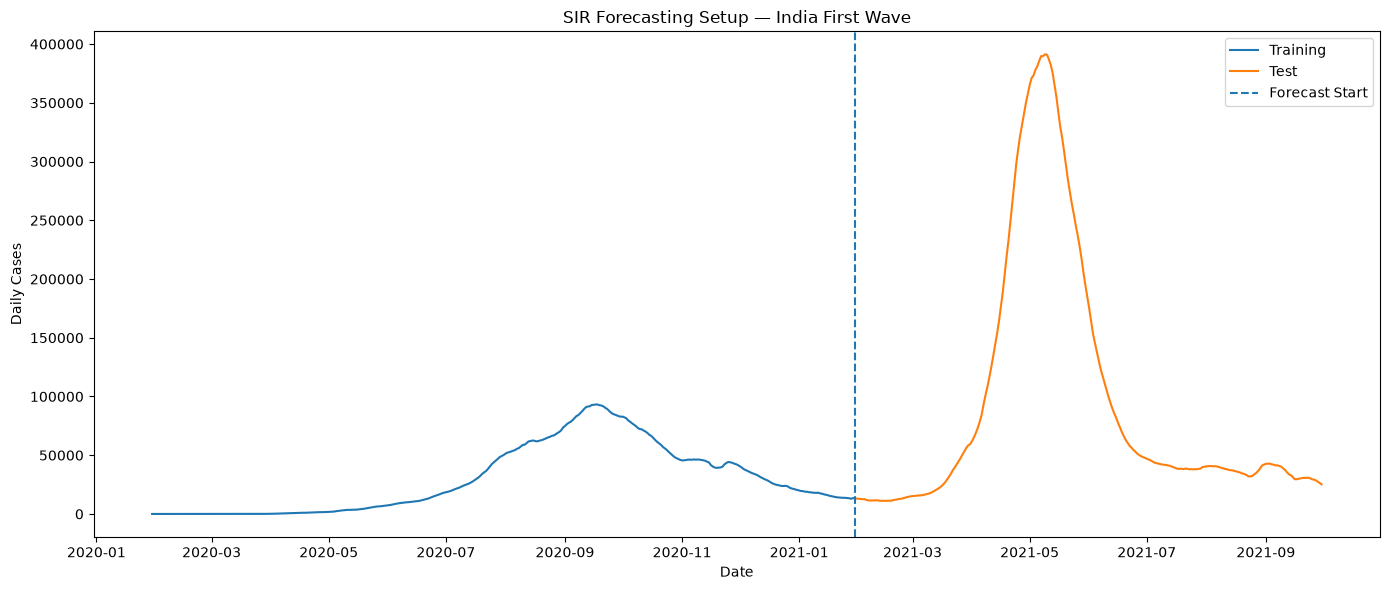

In [92]:
plt.figure(figsize=(14, 6))

plt.plot(
    train_df['date'],
    train_df['new_cases_smoothed'],
    label='Training'
)

plt.plot(
    test_df['date'],
    test_df['new_cases_smoothed'],
    label='Test'
)

plt.axvline(
    TRAIN_END,
    linestyle='--',
    label='Forecast Start'
)

plt.xlabel('Date')
plt.ylabel('Daily Cases')
plt.title('SIR Forecasting Setup — India First Wave')

plt.legend()
plt.tight_layout()
plt.show()

In [93]:
print("N :", N)
print("S0:", S0)
print("I0:", I0)
print("R0:", R0)

print("\nCheck:")
print(S0 + I0 + R0)

N : 1400000000
S0: 1399999999.0
I0: 1.0
R0: 0

Check:
1400000000.0


In [94]:
def sir_model(t, y, beta, gamma, N):

    S, I, R = y

    dSdt = -beta * S * I / N

    dIdt = beta * S * I / N - gamma * I

    dRdt = gamma * I

    return [dSdt, dIdt, dRdt]

In [95]:
def simulate_sir(
    beta,
    gamma,
    t,
    N,
    S0,
    I0,
    R0
):

    solution = solve_ivp(
        sir_model,
        [t.min(), t.max()],
        [S0, I0, R0],
        args=(beta, gamma, N),
        t_eval=t
    )

    S = solution.y[0]
    I = solution.y[1]
    R = solution.y[2]

    return S, I, R

In [133]:
avg_Rt = train_df['reproduction_rate'].median()

print("Median reproduction rate:", avg_Rt)

gamma_test = 1 / 7
beta_test = avg_Rt * gamma_test

print("gamma test:", gamma_test)
print("beta test:", beta_test)

Median reproduction rate: 1.1727
gamma test: 0.14285714285714285
beta test: 0.16752857142857144


In [134]:
S_test, I_test, R_test = simulate_sir(
    beta_test,
    gamma_test,
    train_df['t'].values,
    N,
    S0,
    I0,
    R0
)

print(S_test[:5])
print(I_test[:5])
print(R_test[:5])

[1.4e+09 1.4e+09 1.4e+09 1.4e+09 1.4e+09]
[1.         1.02497829 1.05058053 1.07682231 1.10371954]
[0.         0.14463397 0.29288088 0.44483098 0.6005764 ]


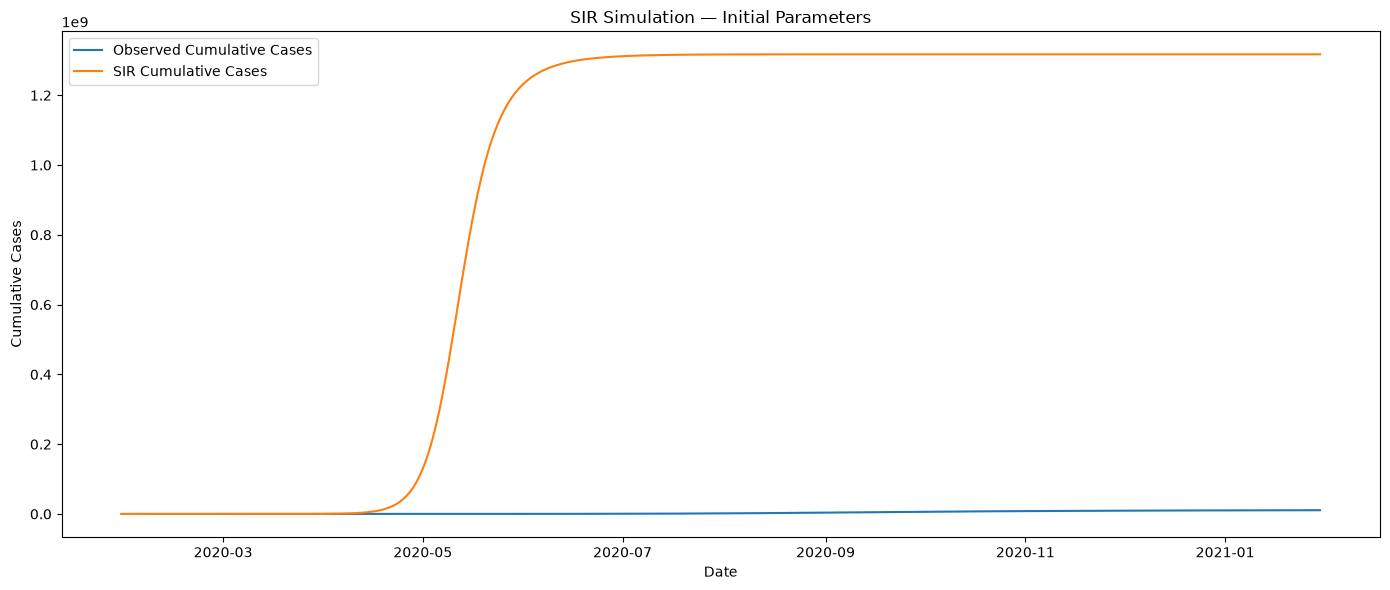

In [135]:
plt.figure(figsize=(14, 6))

plt.plot(
    train_df['date'],
    train_df['total_cases'],
    label='Observed Cumulative Cases'
)

plt.plot(
    train_df['date'],
    predicted_cumulative,
    label='SIR Cumulative Cases'
)

plt.xlabel('Date')
plt.ylabel('Cumulative Cases')
plt.title('SIR Simulation — Initial Parameters')

plt.legend()
plt.tight_layout()
plt.show()

In [136]:
def residuals(
    params,
    t,
    observed_cumulative,
    N,
    S0,
    I0,
    R0
):

    beta, gamma = params

    S, I, R = simulate_sir(
        beta,
        gamma,
        t,
        N,
        S0,
        I0,
        R0
    )

    predicted_cumulative = N - S

    return (
        predicted_cumulative - observed_cumulative
    ) / N

In [141]:
initial_params = [
    0.1465875,   # beta
    0.14285714285714285    # gamma
]

result = least_squares(
    residuals,
    initial_params,
    bounds=(
        [0.0001, 0.0001],
        [5.0, 1.0]
    ),
    args=(
        train_df['t'].values,
        train_df['observed_cumulative'].values,
        N,
        S0,
        I0,
        R0
    )
)

In [142]:
beta_estimated = result.x[0]
gamma_estimated = result.x[1]

R0_estimated = beta_estimated / gamma_estimated

print(f"Estimated β: {beta_estimated:.4f}")
print(f"Estimated γ: {gamma_estimated:.4f}")
print(f"Estimated R₀: {R0_estimated:.4f}")

Estimated β: 1.0373
Estimated γ: 1.0000
Estimated R₀: 1.0373


In [143]:
print("Optimization successful:", result.success)
print("Message:", result.message)
print("Cost:", result.cost)

Optimization successful: True
Message: `ftol` termination condition is satisfied.
Cost: 0.0013937576054158004


In [144]:
S_train, I_train, R_train = simulate_sir(
    beta_estimated,
    gamma_estimated,
    train_df['t'].values,
    N,
    S0,
    I0,
    R0
)

In [145]:
train_predicted_cumulative = N - S_train

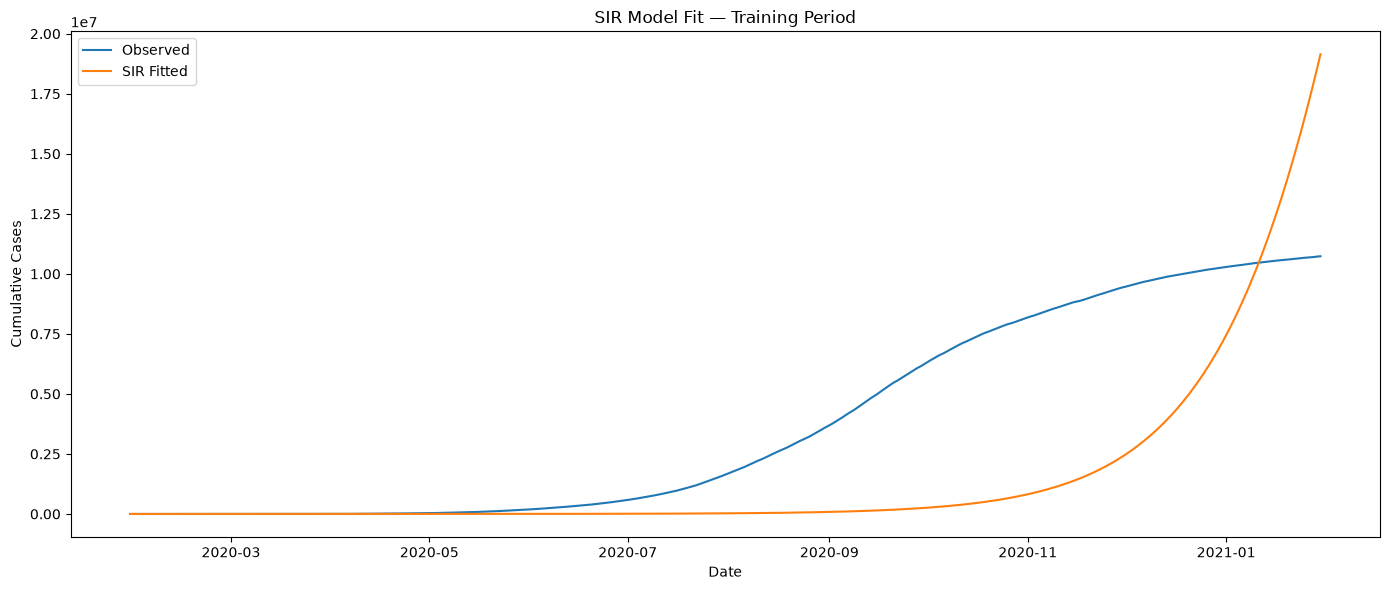

In [146]:
plt.figure(figsize=(14, 6))

plt.plot(
    train_df['date'],
    train_df['total_cases'],
    label='Observed'
)

plt.plot(
    train_df['date'],
    train_predicted_cumulative,
    label='SIR Fitted'
)

plt.xlabel('Date')
plt.ylabel('Cumulative Cases')
plt.title('SIR Model Fit — Training Period')

plt.legend()
plt.tight_layout()
plt.show()

### Forecasting

In [113]:
forecast_t = sir_df[
    sir_df['date'] <= TEST_END
]['t'].values

In [114]:
S_forecast, I_forecast, R_forecast = simulate_sir(
    beta_estimated,
    gamma_estimated,
    forecast_t,
    N,
    S0,
    I0,
    R0
)

In [115]:
forecast_cumulative = N - S_forecast

forecast_df = sir_df[
    sir_df['date'] <= TEST_END
][['date', 't']].copy()

forecast_df['predicted_cumulative'] = forecast_cumulative

In [116]:
forecast_df['predicted_new_cases'] = (
    forecast_df['predicted_cumulative'].diff()
)

In [117]:
forecast_df['predicted_new_cases'] = (
    forecast_df['predicted_new_cases']
    .clip(lower=0)
)

In [118]:
comparison = forecast_df.merge(
    sir_df[
        ['date', 'new_cases_smoothed']
    ],
    on='date',
    how='left'
)

In [119]:
comparison = comparison.rename(
    columns={
        'new_cases_smoothed': 'actual_cases'
    }
)

In [120]:
comparison.head()

,date,t,predicted_cumulative,predicted_new_cases,actual_cases
0,2020-01-30,0,1.000000,NaN,0.142857
1,2020-01-31,1,2.056932,1.056932,0.142857
2,2020-02-01,2,3.154069,1.097137,0.142857
3,2020-02-02,3,4.292974,1.138904,0.285714
4,2020-02-03,4,5.475206,1.182232,0.428571


In [121]:
test_comparison = comparison[
    (comparison['date'] > TRAIN_END) &
    (comparison['date'] <= TEST_END)
].copy()

In [122]:
mae = mean_absolute_error(
    test_comparison['actual_cases'],
    test_comparison['predicted_new_cases']
)

rmse = np.sqrt(
    mean_squared_error(
        test_comparison['actual_cases'],
        test_comparison['predicted_new_cases']
    )
)

print(f"Test MAE: {mae:,.2f}")
print(f"Test RMSE: {rmse:,.2f}")

Test MAE: 264,266.08
Test RMSE: 431,658.65


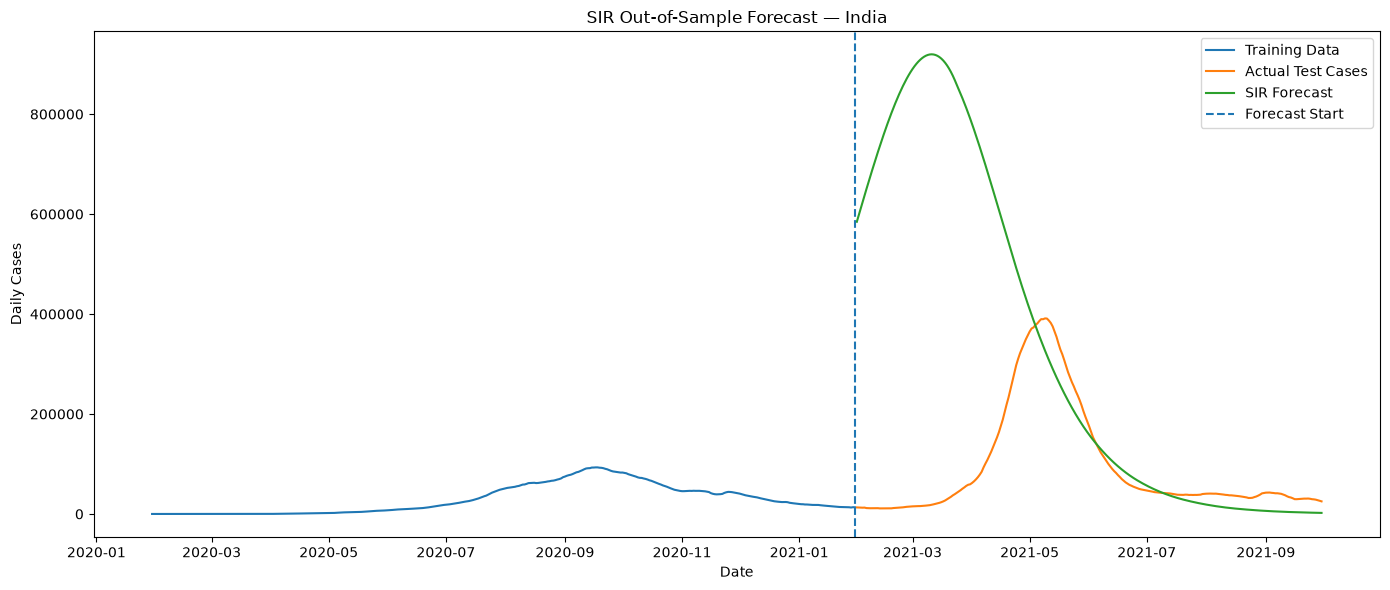

In [123]:
plt.figure(figsize=(14, 6))

plt.plot(
    train_df['date'],
    train_df['new_cases_smoothed'],
    label='Training Data'
)

plt.plot(
    test_comparison['date'],
    test_comparison['actual_cases'],
    label='Actual Test Cases'
)

plt.plot(
    test_comparison['date'],
    test_comparison['predicted_new_cases'],
    label='SIR Forecast'
)

plt.axvline(
    TRAIN_END,
    linestyle='--',
    label='Forecast Start'
)

plt.xlabel('Date')
plt.ylabel('Daily Cases')
plt.title('SIR Out-of-Sample Forecast — India')

plt.legend()
plt.tight_layout()
plt.show()

In [130]:
test_comparison['residual'] = (
    test_comparison['actual_cases']
    - test_comparison['predicted_new_cases']
)

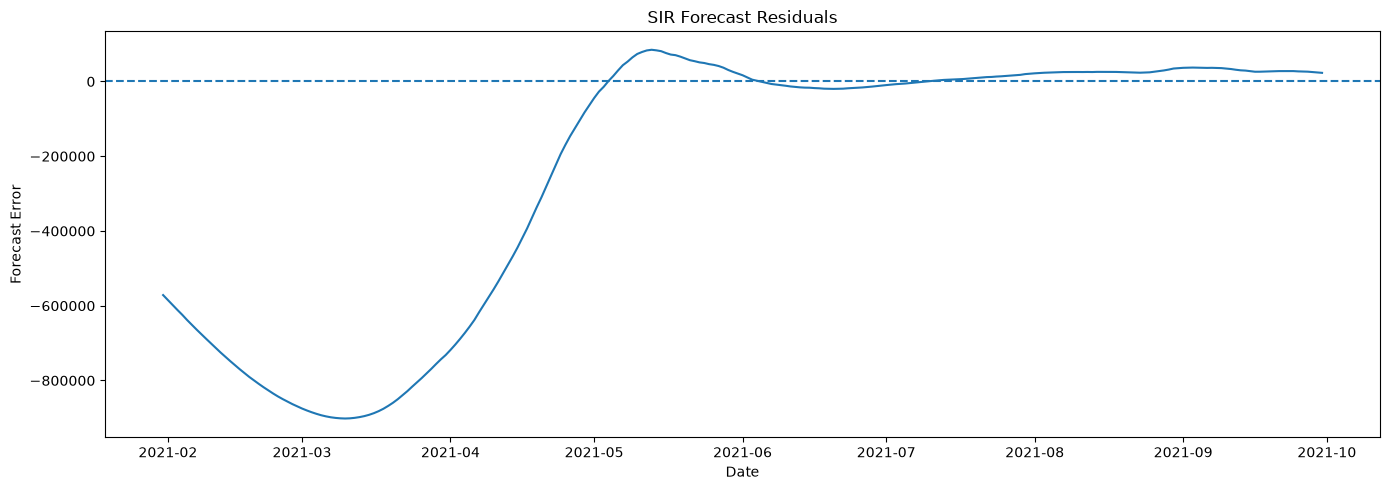

In [131]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_comparison['date'],
    test_comparison['residual']
)

plt.axhline(
    0,
    linestyle='--'
)

plt.xlabel('Date')
plt.ylabel('Forecast Error')
plt.title('SIR Forecast Residuals')

plt.tight_layout()
plt.show()

At the beginning of the 2021 test period, you have extremely large negative residuals (~−900k). Then they rapidly move toward zero around May. This means the SIR forecast is massively overpredicting the number of cases early in the test period. That is characteristic of a model that doesn't properly capture the changing epidemic dynamics.

In [132]:
R0_estimated = beta_estimated / gamma_estimated
print(
    f"Estimated basic reproduction number R₀: "
    f"{R0_estimated:.3f}"
)

Estimated basic reproduction number R₀: 1.037


## SIR Model — Baseline Forecast

The **Susceptible–Infected–Recovered (SIR)** model is a mechanistic epidemiological model that divides the population into three compartments:

- **S (Susceptible):** individuals who can become infected
- **I (Infected):** individuals currently capable of transmitting the disease
- **R (Recovered/Removed):** individuals who have left the infectious population

The model is governed by:

$$
\frac{dS}{dt} = -\frac{\beta SI}{N}
$$

$$
\frac{dI}{dt} = \frac{\beta SI}{N} - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

### Parameters Used

| Parameter | Value / Method | Reason |
|---|---|---|
| Population \(N\) | ~1.4 billion | Approximate population of India |
| gamma | \(1/8 -  0.125\) | Assumes a 8-day average infectious period |
| beta | Estimated using least squares | Allows the model to learn the transmission rate from observed data |
| Initial beta | Based on median `reproduction_rate × γ` | Provides an epidemiologically informed starting value |
| I0 | Initial reported cases (baseline assumption) | Provides the initial infected population |
| R0 | 0 | Simplification at the beginning of the modeled period |

### Training and Testing Strategy

The model was trained on the **2020 COVID-19 wave in India**. The subsequent **2021 second wave was kept completely out-of-sample as the test period**.

This setup evaluates whether parameters learned from one epidemic wave can generalize to a future wave without refitting.

### Why This Version Is Better

The updated approach improves on the initial SIR implementation by:

- Using an epidemiologically informed estimate of \(\gamma\) rather than arbitrarily initializing both parameters.
- Using the observed reproduction rate to obtain a more meaningful initial estimate for \(\beta\).
- Optimizing \(\beta\) using **least-squares estimation** against observed cumulative cases.
- Evaluating the model on a **future COVID wave rather than randomly splitting the data**.
- Deriving predicted daily cases from the change in the susceptible population rather than incorrectly treating the SIR infected compartment \(I(t)\) as daily reported cases.

### Result & Limitation

Although this formulation provides a more principled SIR baseline, it **does not generalize well to India's 2021 second wave**. A basic SIR model assumes a constant transmission rate and a relatively simple epidemic progression, while COVID-19 transmission changed substantially due to interventions, mobility, behavior, variants, immunity, and other factors.

Therefore, the model can capture the **general dynamics of a single epidemic wave**, but it is insufficient for reliably forecasting a subsequent wave with different transmission characteristics.

This limitation motivates the next stage of the project: comparing SIR with **statistical and machine-learning forecasting models** that can better capture changing temporal patterns.